<a href="https://colab.research.google.com/github/OmarSyedK/Gym-Fitness-Progress-Tracker-Python-Data-Analytics-Project/blob/main/gym_fitness_prog_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Loading Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fitness_workout_log.csv to fitness_workout_log (1).csv


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'fitness_workout_log.csv', 'fitness_workout_log (1).csv', 'sample_data']


In [ ]:
import pandas as pd
df = pd.read_csv('/content/fitness_workout_log.csv')


# Step 2: Analyzing dataset

In [ ]:
df.head()

,Date,Workout_Type,Duration_Minutes,Calories_Burned,Body_Weight_KG,Reps_or_Sets,Notes
0,2026-03-19,Strength,63.0,327.0,84.8,3x11,Upper body push
1,2026-03-20,Flexibility,22.0,66.0,84.8,NaN,Deep stretching
2,2026-03-21,Flexibility,29.0,89.0,84.8,NaN,Mobility routine
3,2026-03-22,Strength,59.0,367.0,84.7,4x10,Full body hypertrophy
4,2026-03-23,Strength,65.0,383.0,84.7,4x11,Upper body push


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              90 non-null     object 
 1   Workout_Type      87 non-null     object 
 2   Duration_Minutes  87 non-null     float64
 3   Calories_Burned   87 non-null     float64
 4   Body_Weight_KG    90 non-null     float64
 5   Reps_or_Sets      22 non-null     object 
 6   Notes             90 non-null     object 
dtypes: float64(3), object(4)
memory usage: 5.1+ KB


In [ ]:
df.describe()

,Duration_Minutes,Calories_Burned,Body_Weight_KG
count,87.000000,87.000000,90.000000
mean,39.839080,328.666667,167.837778
std,26.121751,502.192696,242.546009
min,-45.000000,0.000000,80.100000
25%,24.500000,98.500000,81.700000
50%,38.000000,298.000000,82.500000
75%,58.500000,409.500000,84.300000
max,86.000000,4500.000000,850.300000


# Step 3: Cleaning Data

In [ ]:
# Missing values
print(df.isnull().sum())

# Negative durations
print("\nNegative Duration Records")
print(df[df['Duration_Minutes'] < 0])

# Unrealistic calories
print("\nUnrealistic Calories")
print(df[df['Calories_Burned'] > 1500])

# Unrealistic weight
print("\nUnrealistic Weight")
print(df[df['Body_Weight_KG'] > 200])

Date                 0
Workout_Type         3
Duration_Minutes     3
Calories_Burned      3
Body_Weight_KG       0
Reps_or_Sets        68
Notes                0
dtype: int64

Negative Duration Records
          Date Workout_Type  Duration_Minutes  Calories_Burned  \
28  2026-04-16       Cardio             -45.0            298.0   

    Body_Weight_KG Reps_or_Sets          Notes  
28            82.9          NaN  Treadmill run  

Unrealistic Calories
          Date Workout_Type  Duration_Minutes  Calories_Burned  \
60  2026-05-18  Flexibility              22.0           4500.0   

    Body_Weight_KG Reps_or_Sets         Notes  
60            81.3          NaN  Vinyasa Yoga  

Unrealistic Weight
          Date Workout_Type  Duration_Minutes  Calories_Burned  \
80  2026-06-07       Sports              60.0            653.0   
81  2026-06-08       Cardio              58.0            443.0   
82  2026-06-09     Strength              67.0            344.0   
83  2026-06-10  Flexibility      

In [ ]:
df['Date'] = pd.to_datetime(df['Date']) #Converting date column from object to datetime

In [ ]:
# Fill missing values

df['Workout_Type'] = df['Workout_Type'].fillna('Rest Day')

df['Duration_Minutes'] = df['Duration_Minutes'].fillna(0)

df['Calories_Burned'] = df['Calories_Burned'].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              90 non-null     datetime64[ns]
 1   Workout_Type      90 non-null     object        
 2   Duration_Minutes  90 non-null     float64       
 3   Calories_Burned   90 non-null     float64       
 4   Body_Weight_KG    90 non-null     float64       
 5   Reps_or_Sets      22 non-null     object        
 6   Notes             90 non-null     object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 5.1+ KB


In [ ]:
# Replacing negative values with absolute values

df['Duration_Minutes'] = df['Duration_Minutes'].abs()

In [ ]:
# Replacing unrealistic calories (above 1500) with median value

median_calories = df.loc[df['Calories_Burned'] <= 1500, 'Calories_Burned'].median()

df.loc[df['Calories_Burned'] > 1500, 'Calories_Burned'] = median_calories

In [ ]:
# Replacing unrealistic weights (above 200kg) with median value

median_weight = df.loc[df['Body_Weight_KG'] <= 200, 'Body_Weight_KG'].median()

df.loc[df['Body_Weight_KG'] > 200, 'Body_Weight_KG'] = median_weight

In [ ]:
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

                      Date  Duration_Minutes  Calories_Burned  Body_Weight_KG
count                   90         90.000000        90.000000       90.000000
mean   2026-05-02 12:00:00         39.511111       270.722222       82.545556
min    2026-03-19 00:00:00          0.000000         0.000000       80.100000
25%    2026-04-10 06:00:00         24.000000        87.500000       81.700000
50%    2026-05-02 12:00:00         38.000000       271.000000       82.400000
75%    2026-05-24 18:00:00         58.000000       395.750000       83.675000
max    2026-06-16 00:00:00         86.000000       913.000000       84.800000
std                    NaN         25.142848       220.167813        1.287028

Missing Values:
Date                 0
Workout_Type         0
Duration_Minutes     0
Calories_Burned      0
Body_Weight_KG       0
Reps_or_Sets        68
Notes                0
dtype: int64


# Step 4: Weekly Analysis

In [ ]:
df['Week'] = df['Date'].dt.isocalendar().week
df[['Date', 'Week']].head()

,Date,Week
0,2026-03-19,12
1,2026-03-20,12
2,2026-03-21,12
3,2026-03-22,12
4,2026-03-23,13


In [ ]:
weekly_summary = df.groupby('Week').agg({
    'Duration_Minutes': 'mean',
    'Calories_Burned': 'sum',
    'Workout_Type': 'count'
})

weekly_summary.columns = [
    'Avg_Duration',
    'Total_Calories',
    'Workouts_Completed'
]

weekly_summary

,Avg_Duration,Total_Calories,Workouts_Completed
Week,,,
12,43.250000,849.0,4
13,50.142857,2330.0,7
14,23.142857,1192.0,7
15,31.714286,1597.0,7
16,42.000000,1722.0,7
17,43.142857,2063.0,7
18,32.428571,1612.0,7
19,34.714286,1637.0,7
20,56.000000,2455.0,7


In [ ]:
best_week = weekly_summary['Total_Calories'].idxmax()

print("Most Active Week:", best_week)
print(weekly_summary.loc[best_week])

Most Active Week: 24
Avg_Duration            50.571429
Total_Calories        2749.000000
Workouts_Completed       7.000000
Name: 24, dtype: float64


In [ ]:
worst_week = weekly_summary['Total_Calories'].idxmin()

print("Least Active Week:", worst_week)
print(weekly_summary.loc[worst_week])

Least Active Week: 25
Avg_Duration           34.0
Total_Calories        621.0
Workouts_Completed      2.0
Name: 25, dtype: float64


In [ ]:
print(
    "Average Weekly Duration:",
    weekly_summary['Avg_Duration'].mean()
)

Average Weekly Duration: 39.34438775510204


In [ ]:
print("\nWeekly Fitness Summary")
print(weekly_summary.round(2))


Weekly Fitness Summary
      Avg_Duration  Total_Calories  Workouts_Completed
Week                                                  
12           43.25           849.0                   4
13           50.14          2330.0                   7
14           23.14          1192.0                   7
15           31.71          1597.0                   7
16           42.00          1722.0                   7
17           43.14          2063.0                   7
18           32.43          1612.0                   7
19           34.71          1637.0                   7
20           56.00          2455.0                   7
21           39.00          1867.0                   7
22           42.00          2242.0                   7
23           28.71          1429.0                   7
24           50.57          2749.0                   7
25           34.00           621.0                   2


# Step 5: Weight Trend

In [ ]:
# Extracting weight column
import numpy as np
weights = df['Body_Weight_KG'].values
print(weights[:10])  # first 10 values

[84.8 84.8 84.8 84.7 84.7 84.6 84.5 84.4 84.4 84.3]


In [ ]:
start_weight = np.round(weights[0], 2)
print("Starting Weight:", start_weight, "kg")

end_weight = np.round(weights[-1], 2)
print("Ending Weight:", end_weight, "kg")

Starting Weight: 84.8 kg
Ending Weight: 82.4 kg


In [ ]:
# Weight lost
weight_change = np.round(end_weight - start_weight, 2)

if weight_change < 0:
    print("Weight Lost:", abs(weight_change), "kg")
else:
    print("Weight Gained:", weight_change, "kg")

Weight Lost: 2.4 kg


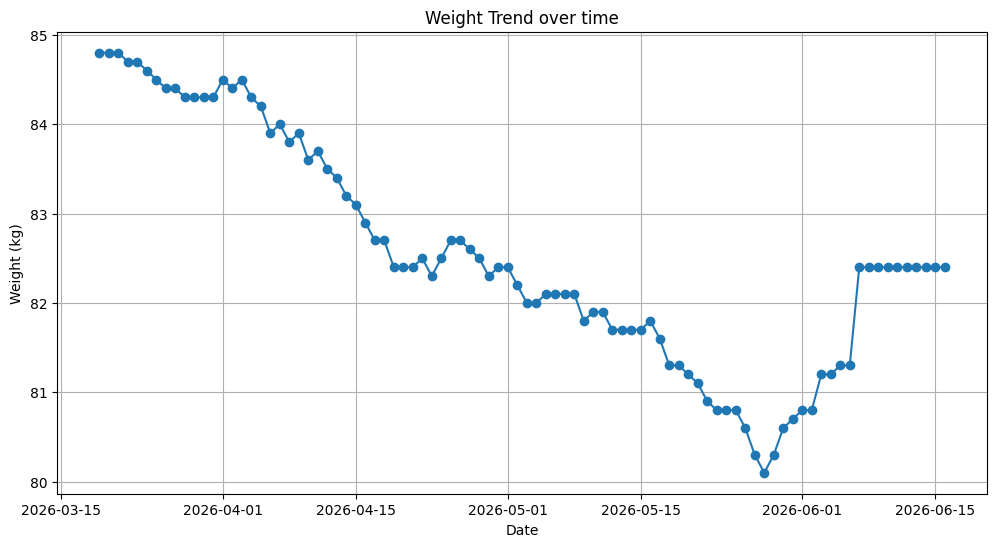

In [ ]:
# Weight trend line chart
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

plt.plot(
    df['Date'],
    df['Body_Weight_KG'],
    marker = 'o'
)

plt.title('Weight Trend over time')
plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.grid(True)

plt.show()


In [ ]:
print("\nFitness Progress Summary")
print("------------------------")
print("Starting Weight:", start_weight, "kg")
print("Ending Weight:", end_weight, "kg")
print("Average Weight:", np.round(np.mean(weights), 2), "kg")

if weight_change < 0:
    print("Total Weight Lost:", abs(weight_change), "kg")
else:
    print("Total Weight Gained:", weight_change, "kg")


Fitness Progress Summary
------------------------
Starting Weight: 84.8 kg
Ending Weight: 82.4 kg
Average Weight: 82.55 kg
Total Weight Lost: 2.4 kg


# Step 6: Workout Distribution

In [ ]:
workout_counts = df['Workout_Type'].value_counts()
print(workout_counts)

Workout_Type
Flexibility    22
Strength       21
Cardio         21
Rest           13
Sports         10
Rest Day        3
Name: count, dtype: int64


In [ ]:
most_common = workout_counts.idxmax()
least_common = workout_counts.idxmin()

print("Most Frequent Workout:", most_common)
print("Least Frequent Workout:", least_common)

Most Frequent Workout: Flexibility
Least Frequent Workout: Rest Day


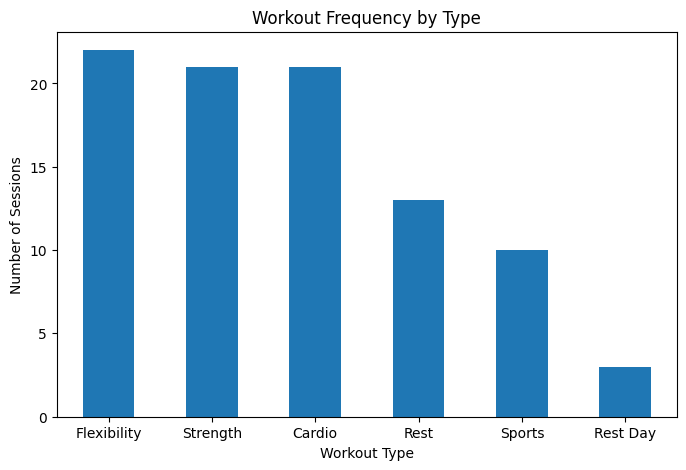

In [ ]:
plt.figure(figsize=(8,5))

workout_counts.plot(
    kind='bar'
)

plt.title('Workout Frequency by Type')
plt.xlabel('Workout Type')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=0)

plt.show()

# Step 7: Performance Insights

In [ ]:
best_week = weekly_summary['Total_Calories'].idxmax()

print("Best Week:", best_week)
print(weekly_summary.loc[best_week])

Best Week: 24
Avg_Duration            50.571429
Total_Calories        2749.000000
Workouts_Completed       7.000000
Name: 24, dtype: float64


In [ ]:
max_calories = df['Calories_Burned'].max()

max_calorie_day = df.loc[
    df['Calories_Burned'].idxmax()
]

print("Most Calories Burned in a Day:", max_calories)

print("\nRecord:")
print(max_calorie_day)

Most Calories Burned in a Day: 913.0

Record:
Date                2026-05-28 00:00:00
Workout_Type                     Sports
Duration_Minutes                   85.0
Calories_Burned                   913.0
Body_Weight_KG                     80.1
Reps_or_Sets                        NaN
Notes                     Swimming laps
Week                                 22
Name: 70, dtype: object


In [ ]:
avg_duration = df['Duration_Minutes'].mean()

print( "Average Session Duration:", round(avg_duration, 2), "minutes")

Average Session Duration: 39.51 minutes


# Step 8: Monthly Summary

In [ ]:
df['Month'] = df['Date'].dt.strftime('%Y-%m')
df[['Date', 'Month']].head()

,Date,Month
0,2026-03-19,2026-03
1,2026-03-20,2026-03
2,2026-03-21,2026-03
3,2026-03-22,2026-03
4,2026-03-23,2026-03


In [ ]:
monthly_summary = df.groupby('Month').agg({
    'Workout_Type': 'count',
    'Calories_Burned': 'sum',
    'Body_Weight_KG': 'mean'
})

monthly_summary.columns = [
    'Total_Workouts',
    'Total_Calories_Burned',
    'Average_Weight_KG'
]

monthly_summary = monthly_summary.round(2)

print(monthly_summary)

         Total_Workouts  Total_Calories_Burned  Average_Weight_KG
Month                                                            
2026-03              13                 3179.0              84.53
2026-04              30                 7684.0              83.20
2026-05              31                 8703.0              81.41
2026-06              16                 4799.0              81.91


In [ ]:
best_month = monthly_summary['Total_Calories_Burned'].idxmax()
print("Best Month:", best_month)

Best Month: 2026-05


In [ ]:
print("\n===== MONTHLY FITNESS SUMMARY =====")
print(monthly_summary)
print("\nBest Month (Calories Burned):", best_month)


===== MONTHLY FITNESS SUMMARY =====
         Total_Workouts  Total_Calories_Burned  Average_Weight_KG
Month                                                            
2026-03              13                 3179.0              84.53
2026-04              30                 7684.0              83.20
2026-05              31                 8703.0              81.41
2026-06              16                 4799.0              81.91

Best Month (Calories Burned): 2026-05


Final Expected Outputs

In [ ]:
df.head()

,Date,Workout_Type,Duration_Minutes,Calories_Burned,Body_Weight_KG,Reps_or_Sets,Notes,Week,Month
0,2026-03-19,Strength,63.0,327.0,84.8,3x11,Upper body push,12,2026-03
1,2026-03-20,Flexibility,22.0,66.0,84.8,NaN,Deep stretching,12,2026-03
2,2026-03-21,Flexibility,29.0,89.0,84.8,NaN,Mobility routine,12,2026-03
3,2026-03-22,Strength,59.0,367.0,84.7,4x10,Full body hypertrophy,12,2026-03
4,2026-03-23,Strength,65.0,383.0,84.7,4x11,Upper body push,13,2026-03


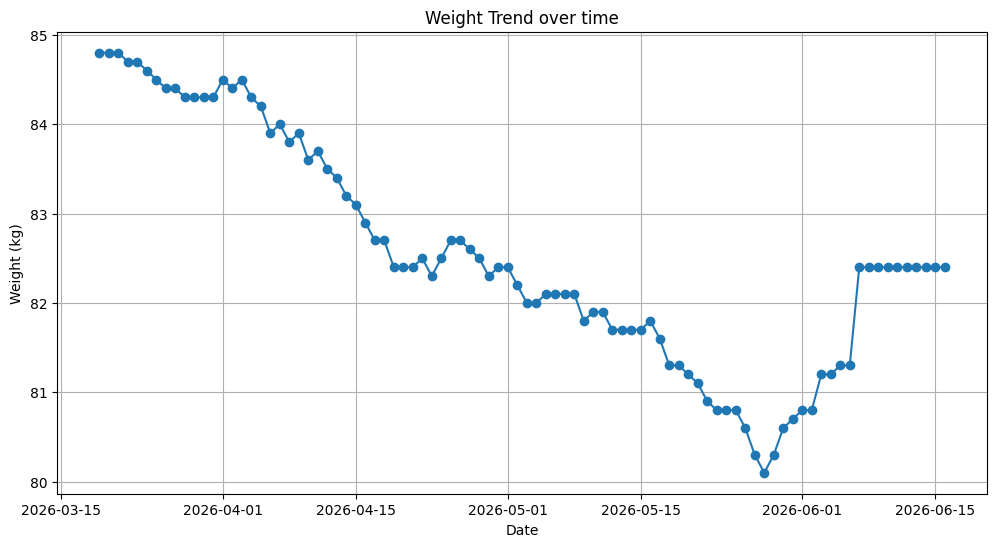

In [ ]:
# Line chart showing body weight trend over 90 days

plt.figure(figsize = (12,6))
plt.plot(
    df['Date'],
    df['Body_Weight_KG'],
    marker = 'o'
)
plt.title('Weight Trend over time')
plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()

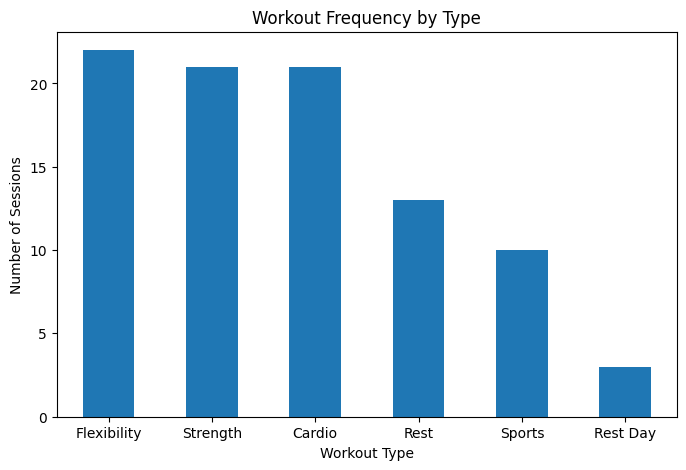

In [ ]:
# Bar chart showing workout frequency by type

plt.figure(figsize=(8,5))
workout_counts.plot(
    kind='bar'
)
plt.title('Workout Frequency by Type')
plt.xlabel('Workout Type')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Weekly summary table: workouts completed, calories burned, avg duration
print("\nWeekly Fitness Summary")
print(weekly_summary.round(2))


Weekly Fitness Summary
      Avg_Duration  Total_Calories  Workouts_Completed
Week                                                  
12           43.25           849.0                   4
13           50.14          2330.0                   7
14           23.14          1192.0                   7
15           31.71          1597.0                   7
16           42.00          1722.0                   7
17           43.14          2063.0                   7
18           32.43          1612.0                   7
19           34.71          1637.0                   7
20           56.00          2455.0                   7
21           39.00          1867.0                   7
22           42.00          2242.0                   7
23           28.71          1429.0                   7
24           50.57          2749.0                   7
25           34.00           621.0                   2


In [ ]:
# Printed insights: best week, worst week, total calories burned

best_week = weekly_summary['Total_Calories'].idxmax()
print("Most Active Week:", best_week)
print(weekly_summary.loc[best_week])

worst_week = weekly_summary['Total_Calories'].idxmin()
print("Least Active Week:", worst_week)
print(weekly_summary.loc[worst_week])

print("Total Calories Burned: ", weekly_summary['Total_Calories'].sum())

Most Active Week: 24
Avg_Duration            50.571429
Total_Calories        2749.000000
Workouts_Completed       7.000000
Name: 24, dtype: float64
Least Active Week: 25
Avg_Duration           34.0
Total_Calories        621.0
Workouts_Completed      2.0
Name: 25, dtype: float64
Total Calories Burned:  24365.0
